# Urban Mobility Demand, Revenue & Operational Efficiency
### NYC TLC Trip Record Data — Yellow + Green Taxi, full year 2023

**Business problem:** How can a mobility business understand demand, revenue performance, and operational patterns to identify opportunities for improving utilization and revenue?

Data source: [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page). ~41M cleaned trip records loaded into a local MySQL database (`nyc_taxi`); see `sql/README_data_quality.md` for cleaning rules applied at ingestion.

This notebook works primarily against **SQL aggregations** (the `sql/*.sql` files) rather than pulling all 41M rows into pandas — the heavy lifting (GROUP BY, window functions, joins) happens in MySQL, and a random trip-level sample is used here for distribution/outlier/correlation work that needs row-level data.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = os.path.dirname(os.getcwd())  # run from notebooks/, so parent is project root
SOCKET = os.path.join(PROJECT_ROOT, "mysql_data", "mysql.sock")
engine = create_engine(f"mysql+pymysql://root@localhost/nyc_taxi?unix_socket={SOCKET}")

def q(sql, **kwargs):
    return pd.read_sql(text(sql), engine, **kwargs)

q("SELECT COUNT(*) AS total_trips, MIN(pickup_datetime) AS min_dt, MAX(pickup_datetime) AS max_dt FROM trips")

## 1. Demand — when and where is demand concentrated?

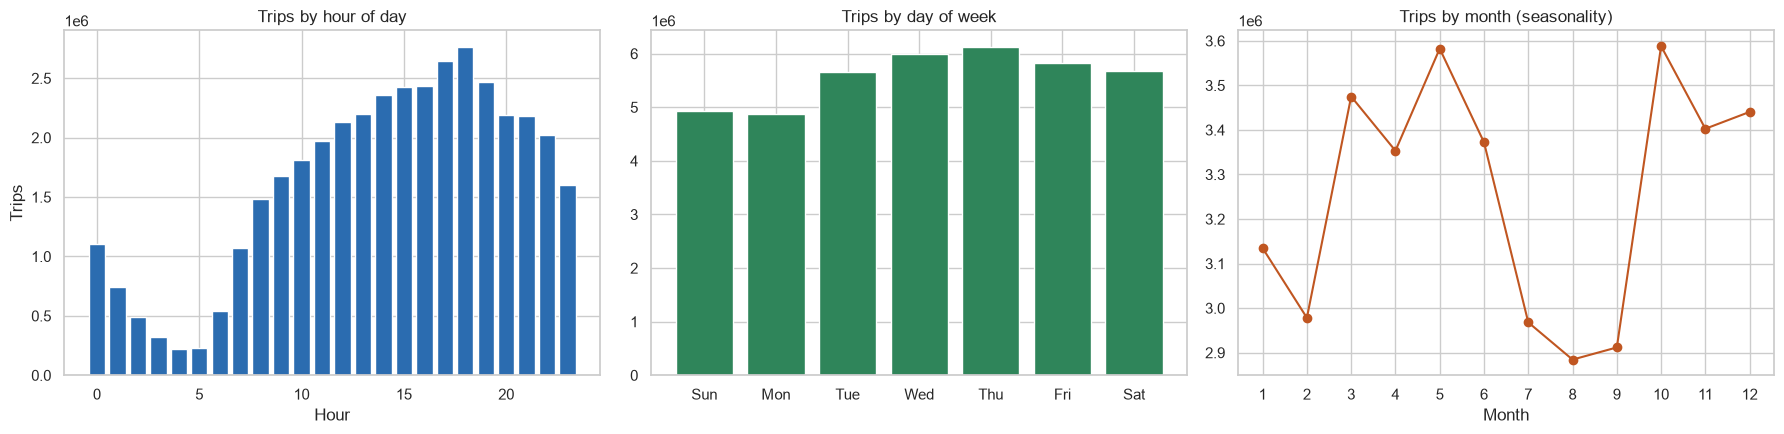

In [2]:
by_hour = q("SELECT pickup_hour, COUNT(*) AS trip_count FROM trips GROUP BY pickup_hour ORDER BY pickup_hour")
by_dow = q("""
    SELECT pickup_dow,
        CASE pickup_dow WHEN 1 THEN 'Sun' WHEN 2 THEN 'Mon' WHEN 3 THEN 'Tue'
             WHEN 4 THEN 'Wed' WHEN 5 THEN 'Thu' WHEN 6 THEN 'Fri' WHEN 7 THEN 'Sat' END AS day_name,
        COUNT(*) AS trip_count
    FROM trips GROUP BY pickup_dow ORDER BY pickup_dow
""")
by_month = q("SELECT pickup_month, COUNT(*) AS trip_count, SUM(total_amount) AS revenue FROM trips GROUP BY pickup_month ORDER BY pickup_month")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].bar(by_hour["pickup_hour"], by_hour["trip_count"], color="#2b6cb0")
axes[0].set_title("Trips by hour of day"); axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Trips")

axes[1].bar(by_dow["day_name"], by_dow["trip_count"], color="#2f855a")
axes[1].set_title("Trips by day of week")

axes[2].plot(by_month["pickup_month"], by_month["trip_count"], marker="o", color="#c05621")
axes[2].set_title("Trips by month (seasonality)"); axes[2].set_xlabel("Month")
axes[2].set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

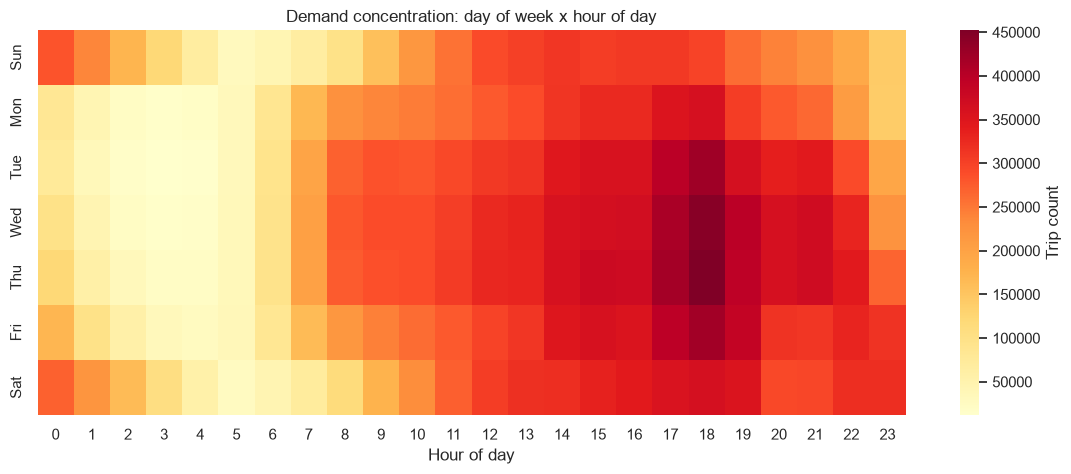

In [3]:
# Demand heatmap: hour-of-day x day-of-week
heatmap_df = q("""
    SELECT pickup_dow, pickup_hour, COUNT(*) AS trip_count
    FROM trips GROUP BY pickup_dow, pickup_hour
""")
pivot = heatmap_df.pivot(index="pickup_dow", columns="pickup_hour", values="trip_count")
pivot.index = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Trip count"})
plt.title("Demand concentration: day of week x hour of day")
plt.xlabel("Hour of day"); plt.ylabel("")
plt.show()

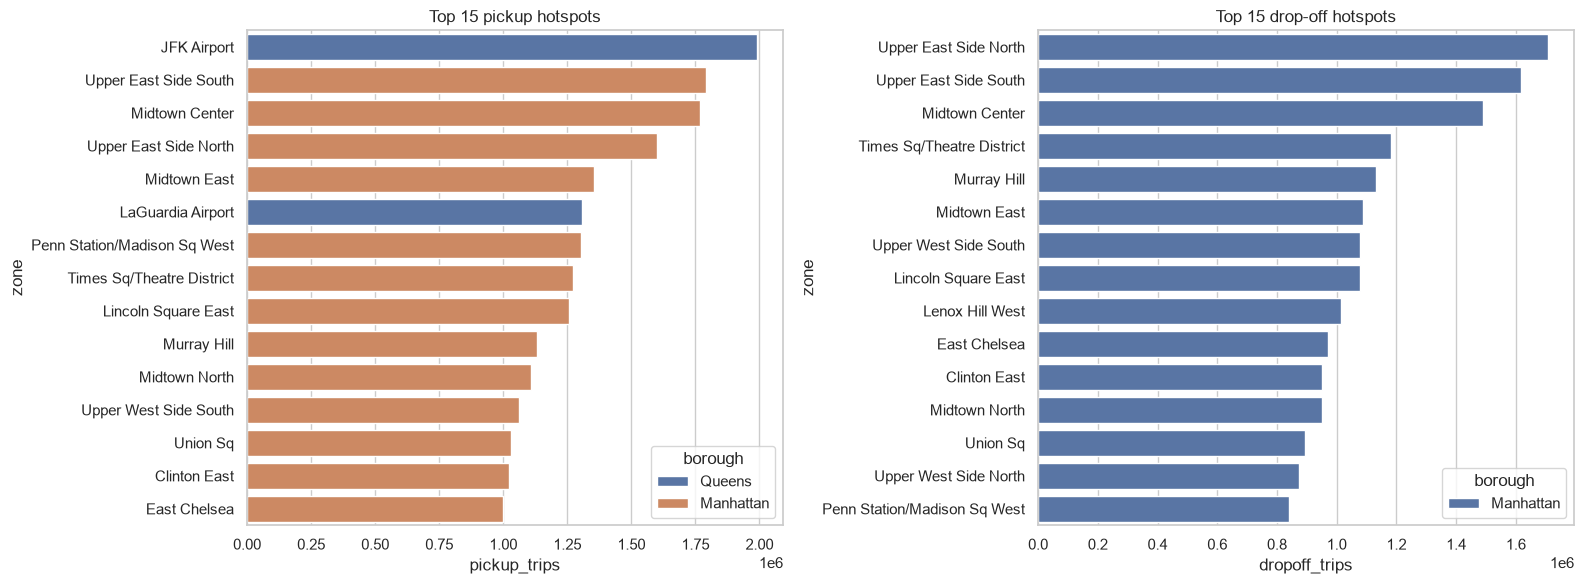

In [4]:
# Pickup & drop-off hotspots
pu_hotspots = q("""
    SELECT z.borough, z.zone, COUNT(*) AS pickup_trips
    FROM trips t JOIN taxi_zones z ON t.pu_location_id = z.location_id
    GROUP BY z.borough, z.zone ORDER BY pickup_trips DESC LIMIT 15
""")
do_hotspots = q("""
    SELECT z.borough, z.zone, COUNT(*) AS dropoff_trips
    FROM trips t JOIN taxi_zones z ON t.do_location_id = z.location_id
    GROUP BY z.borough, z.zone ORDER BY dropoff_trips DESC LIMIT 15
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=pu_hotspots, y="zone", x="pickup_trips", hue="borough", dodge=False, ax=axes[0])
axes[0].set_title("Top 15 pickup hotspots")
sns.barplot(data=do_hotspots, y="zone", x="dropoff_trips", hue="borough", dodge=False, ax=axes[1])
axes[1].set_title("Top 15 drop-off hotspots")
plt.tight_layout()
plt.show()

## 2. Revenue — which periods and locations generate the strongest revenue?

,total_trips,total_fare_revenue,total_tip_revenue,total_revenue,avg_fare_per_trip
0,39091620,"761,675,620.10","136,752,244.38","1,108,470,125.57",28.36


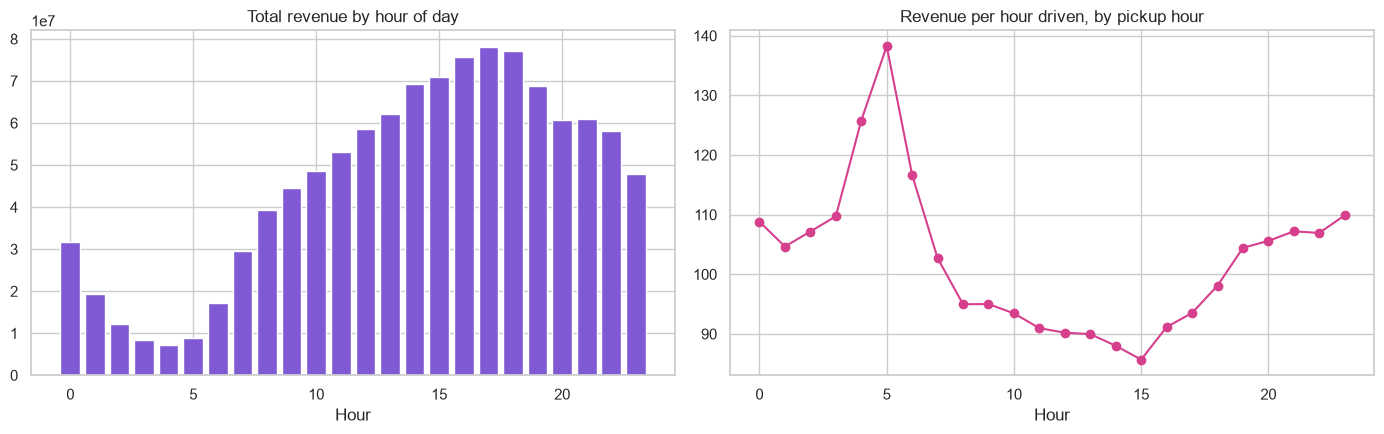

In [5]:
summary = q("""
    SELECT COUNT(*) AS total_trips, SUM(fare_amount) AS total_fare_revenue,
           SUM(tip_amount) AS total_tip_revenue, SUM(total_amount) AS total_revenue,
           AVG(total_amount) AS avg_fare_per_trip
    FROM trips
""")
display(summary)

rev_by_hour = q("""
    SELECT pickup_hour, COUNT(*) AS trip_count, SUM(total_amount) AS revenue,
           SUM(total_amount) / NULLIF(SUM(trip_duration_min), 0) * 60 AS revenue_per_hour_driven
    FROM trips GROUP BY pickup_hour ORDER BY pickup_hour
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(rev_by_hour["pickup_hour"], rev_by_hour["revenue"], color="#805ad5")
axes[0].set_title("Total revenue by hour of day"); axes[0].set_xlabel("Hour")
axes[1].plot(rev_by_hour["pickup_hour"], rev_by_hour["revenue_per_hour_driven"], marker="o", color="#d53f8c")
axes[1].set_title("Revenue per hour driven, by pickup hour"); axes[1].set_xlabel("Hour")
plt.tight_layout()
plt.show()

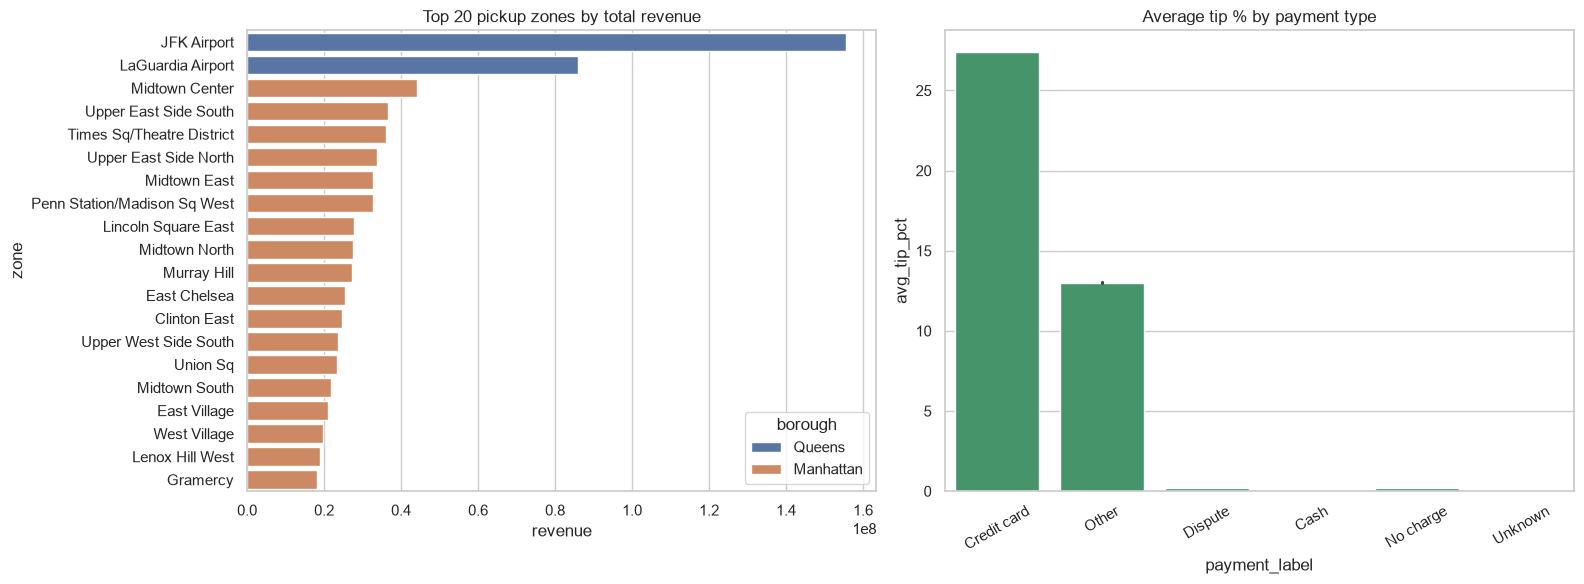

,payment_type,payment_label,trip_count,total_tips,avg_tip_pct
0,1.00,Credit card,30337161,"132,921,359.90",27.38
1,0.00,Other,1307133,"3,629,922.11",13.08
2,NaN,Other,55057,"164,326.29",12.96
3,4.00,Dispute,499132,"22,641.30",0.18
4,2.00,Cash,6646906,"10,896.20",0.00
5,3.00,No charge,246214,"3,098.58",0.19
6,5.00,Unknown,17,0.00,0.00


In [6]:
# Revenue by pickup zone (top 20) + tip revenue by payment type
rev_by_zone = q("""
    SELECT z.borough, z.zone, COUNT(*) AS trip_count, SUM(t.total_amount) AS revenue
    FROM trips t JOIN taxi_zones z ON t.pu_location_id = z.location_id
    GROUP BY z.borough, z.zone ORDER BY revenue DESC LIMIT 20
""")
tips_by_payment = q("""
    SELECT payment_type,
        CASE payment_type WHEN 1 THEN 'Credit card' WHEN 2 THEN 'Cash' WHEN 3 THEN 'No charge'
             WHEN 4 THEN 'Dispute' WHEN 5 THEN 'Unknown' WHEN 6 THEN 'Voided trip' ELSE 'Other' END AS payment_label,
        COUNT(*) AS trip_count, SUM(tip_amount) AS total_tips,
        AVG(CASE WHEN fare_amount > 0 THEN tip_amount / fare_amount END) * 100 AS avg_tip_pct
    FROM trips GROUP BY payment_type ORDER BY total_tips DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=rev_by_zone, y="zone", x="revenue", hue="borough", dodge=False, ax=axes[0])
axes[0].set_title("Top 20 pickup zones by total revenue")
sns.barplot(data=tips_by_payment, x="payment_label", y="avg_tip_pct", ax=axes[1], color="#38a169")
axes[1].set_title("Average tip % by payment type"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
tips_by_payment

## 3. Trip economics — what trip characteristics drive revenue efficiency?

The queries below use SQL aggregation for the distance-band breakdown. For distribution shape, outlier
investigation, and correlation analysis we pull a **random 1M-row sample** at row level (41M rows would
be needlessly heavy for pandas here — the aggregates already answer the business question; the sample
is just to sanity-check relationships and look for outliers).

In [7]:
distance_bands = q("""
    SELECT
        CASE WHEN trip_distance < 1 THEN '< 1 mi' WHEN trip_distance < 3 THEN '1-3 mi'
             WHEN trip_distance < 6 THEN '3-6 mi' WHEN trip_distance < 10 THEN '6-10 mi'
             ELSE '10+ mi' END AS distance_band,
        MIN(trip_distance) AS min_dist,
        COUNT(*) AS trip_count, AVG(total_amount) AS avg_fare,
        AVG(total_amount) / NULLIF(AVG(trip_distance), 0) AS revenue_per_mile,
        AVG(total_amount) / NULLIF(AVG(trip_duration_min), 0) AS revenue_per_minute,
        AVG(CASE WHEN fare_amount > 0 THEN tip_amount / fare_amount END) * 100 AS avg_tip_pct
    FROM trips WHERE trip_distance > 0 AND trip_duration_min > 0
    GROUP BY distance_band ORDER BY min_dist
""").drop(columns="min_dist")
distance_bands

,distance_band,trip_count,avg_fare,revenue_per_mile,revenue_per_minute,avg_tip_pct
0,< 1 mi,8013309,13.90,20.42,1.98,24.63
1,1-3 mi,18960501,20.42,11.58,1.47,20.60
2,3-6 mi,5512774,32.03,7.87,1.37,17.62
3,6-10 mi,2429973,51.48,6.48,1.76,17.54
4,10+ mi,3361531,84.66,5.27,1.84,20.57


In [8]:
# Row-level sample (~1M rows) via trip_id modulo — much faster than ORDER BY RAND() on 41M rows
sample = q("""
    SELECT service_type, trip_distance, trip_duration_min, fare_amount, tip_amount,
           total_amount, passenger_count, payment_type, pickup_hour
    FROM trips
    WHERE trip_id % 40 = 0
      AND trip_distance > 0 AND trip_distance < 50
      AND trip_duration_min > 0 AND trip_duration_min < 180
""")
print(f"sample size: {len(sample):,} rows")
sample.describe()

sample size: 955,866 rows


,trip_distance,trip_duration_min,fare_amount,tip_amount,total_amount,passenger_count,payment_type,pickup_hour
count,"955,866.00","955,866.00","955,866.00","955,866.00","955,866.00","929,113.00","954,541.00","955,866.00"
mean,3.50,16.40,19.32,3.53,28.26,1.37,1.19,14.27
std,4.48,13.14,17.92,3.96,22.74,0.89,0.54,5.79
min,0.01,0.02,-181.50,-90.00,-193.44,0.00,0.00,0.00
25%,1.09,7.73,9.30,1.00,15.95,1.00,1.00,11.00
50%,1.81,12.68,13.50,2.82,21.00,1.00,1.00,15.00
75%,3.48,20.65,21.90,4.42,30.60,1.00,1.00,19.00
max,49.74,179.68,500.00,200.00,513.75,8.00,4.00,23.00


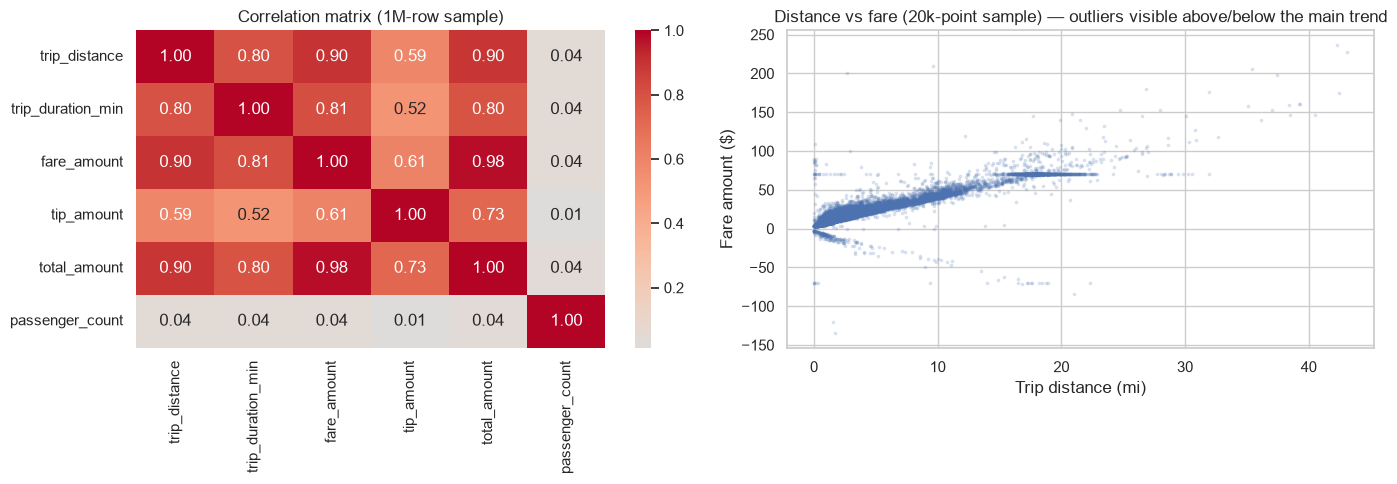

In [9]:
# Correlation analysis + distance vs fare relationship (with outliers visible)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_cols = ["trip_distance", "trip_duration_min", "fare_amount", "tip_amount", "total_amount", "passenger_count"]
sns.heatmap(sample[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Correlation matrix (1M-row sample)")

scatter_sample = sample.sample(20000, random_state=42)
axes[1].scatter(scatter_sample["trip_distance"], scatter_sample["fare_amount"], s=3, alpha=0.15)
axes[1].set_xlabel("Trip distance (mi)"); axes[1].set_ylabel("Fare amount ($)")
axes[1].set_title("Distance vs fare (20k-point sample) — outliers visible above/below the main trend")
plt.tight_layout()
plt.show()

## 4. Operational efficiency — utilization signals from demand patterns

No supply/availability data exists in this dataset, so these are **demand-side utilization proxies**
(pickup concentration, cycle time, low-demand windows) — not claims about actual vehicle shortages.

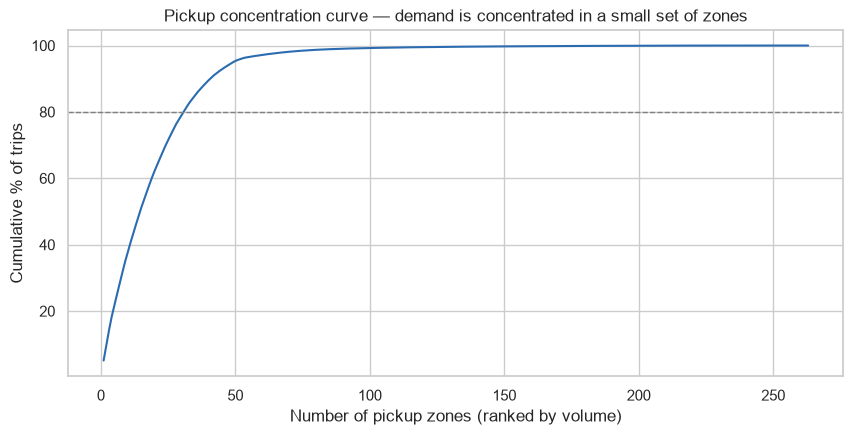

31 zones (out of 263) account for 80% of all pickups


In [10]:
# Pickup concentration: what share of demand comes from a small number of zones?
zone_counts = q("SELECT pu_location_id, COUNT(*) AS trip_count FROM trips GROUP BY pu_location_id")
zone_counts = zone_counts.sort_values("trip_count", ascending=False).reset_index(drop=True)
zone_counts["cum_pct"] = 100 * zone_counts["trip_count"].cumsum() / zone_counts["trip_count"].sum()

plt.figure(figsize=(10, 4.5))
plt.plot(range(1, len(zone_counts) + 1), zone_counts["cum_pct"], color="#2b6cb0")
plt.axhline(80, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Number of pickup zones (ranked by volume)"); plt.ylabel("Cumulative % of trips")
plt.title("Pickup concentration curve — demand is concentrated in a small set of zones")
plt.show()

n_zones_for_80pct = (zone_counts["cum_pct"] < 80).sum() + 1
print(f"{n_zones_for_80pct} zones (out of {len(zone_counts)}) account for 80% of all pickups")

In [11]:
# Low-demand windows worth flagging for fleet reallocation (bottom 20 hour-of-week slots)
low_demand = q("""
    SELECT pickup_dow,
        CASE pickup_dow WHEN 1 THEN 'Sun' WHEN 2 THEN 'Mon' WHEN 3 THEN 'Tue'
             WHEN 4 THEN 'Wed' WHEN 5 THEN 'Thu' WHEN 6 THEN 'Fri' WHEN 7 THEN 'Sat' END AS day_name,
        pickup_hour, COUNT(*) AS trip_count, AVG(total_amount) AS avg_fare
    FROM trips GROUP BY pickup_dow, pickup_hour ORDER BY trip_count ASC LIMIT 20
""")
low_demand

,pickup_dow,day_name,pickup_hour,trip_count,avg_fare
0,3,Tue,3,11677,33.92
1,3,Tue,4,14426,40.34
2,4,Wed,3,15499,29.80
3,2,Mon,3,16485,32.75
4,4,Wed,4,16928,39.76
5,3,Tue,2,18329,30.91
6,2,Mon,4,18793,39.52
7,5,Thu,4,20392,38.32
8,5,Thu,3,20723,28.49
9,2,Mon,2,22963,30.42


## 5. Passenger & payment behavior

Which payment methods are associated with higher tips? How does passenger count relate to fare/trip characteristics?

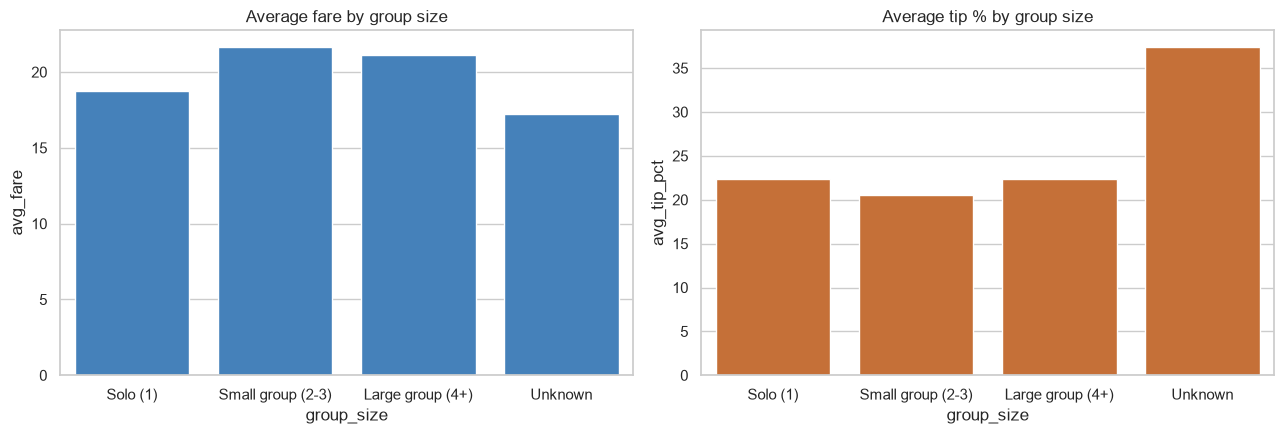

,group_size,trip_count,avg_fare,avg_distance,avg_tip_pct
0,Solo (1),28440354,18.76,3.29,22.34
1,Small group (2-3),7076726,21.66,4.02,20.53
2,Large group (4+),1623219,21.10,3.73,22.37
3,Unknown,589131,17.26,2.81,37.42


In [12]:
passenger_stats = q("""
    SELECT
        CASE WHEN passenger_count = 1 THEN 'Solo (1)'
             WHEN passenger_count BETWEEN 2 AND 3 THEN 'Small group (2-3)'
             WHEN passenger_count >= 4 THEN 'Large group (4+)' ELSE 'Unknown' END AS group_size,
        COUNT(*) AS trip_count, AVG(fare_amount) AS avg_fare, AVG(trip_distance) AS avg_distance,
        AVG(CASE WHEN fare_amount > 0 THEN tip_amount / fare_amount END) * 100 AS avg_tip_pct
    FROM trips WHERE passenger_count IS NOT NULL
    GROUP BY group_size ORDER BY trip_count DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=passenger_stats, x="group_size", y="avg_fare", ax=axes[0], color="#3182ce")
axes[0].set_title("Average fare by group size")
sns.barplot(data=passenger_stats, x="group_size", y="avg_tip_pct", ax=axes[1], color="#dd6b20")
axes[1].set_title("Average tip % by group size")
plt.tight_layout()
plt.show()
passenger_stats

## 6. Export aggregated extracts for the Tableau dashboard

Tableau will connect to these pre-aggregated CSVs rather than the raw 41M-row table — faster to build
against and keeps the dashboard file small. A trip-level sample is also exported for any visuals that
need row-level granularity (e.g. distance/fare scatter).

In [ ]:
EXPORT_DIR = os.path.join(PROJECT_ROOT, "exports")
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1. Trip-level fact table aggregated by date x hour x pickup zone x payment_type x
#    service_type — the main Tableau data source. Drop-off location and calendar
#    fields (month/dow, both derivable from pickup_date in Tableau) are excluded here
#    to keep cardinality manageable; drop-off flow is covered separately below.
main_extract = q("""
    SELECT
        pickup_date, pickup_hour, service_type, pu_location_id, payment_type,
        COUNT(*) AS trip_count,
        SUM(trip_distance) AS total_distance,
        SUM(trip_duration_min) AS total_duration_min,
        SUM(fare_amount) AS fare_revenue,
        SUM(tip_amount) AS tip_revenue,
        SUM(total_amount) AS total_revenue,
        AVG(passenger_count) AS avg_passenger_count
    FROM trips
    GROUP BY pickup_date, pickup_hour, service_type, pu_location_id, payment_type
""")
main_extract.to_csv(f"{EXPORT_DIR}/trips_aggregated.csv", index=False)
print(f"trips_aggregated.csv: {len(main_extract):,} rows")

# 2. Pickup -> drop-off flow matrix at zone-pair grain (for OD flow / imbalance visuals)
od_matrix = q("""
    SELECT pu_location_id, do_location_id, COUNT(*) AS trip_count, SUM(total_amount) AS revenue
    FROM trips GROUP BY pu_location_id, do_location_id
""")
od_matrix.to_csv(f"{EXPORT_DIR}/od_flow_matrix.csv", index=False)
print(f"od_flow_matrix.csv: {len(od_matrix):,} rows")

# 3. Zone lookup (for joining LocationID -> Borough/Zone in Tableau)
zones = q("SELECT * FROM taxi_zones")
zones.to_csv(f"{EXPORT_DIR}/taxi_zones.csv", index=False)

# 4. Row-level sample for scatter/distribution visuals
sample.to_csv(f"{EXPORT_DIR}/trip_sample_1M.csv", index=False)

print("All Tableau extracts written to", EXPORT_DIR)

## Key findings — 39.1M trips, Yellow + Green Taxi, full year 2023

- **Demand:** Concentrated at evening rush (5–7pm, peaking at 6pm with 2.76M trips) and in a small
  footprint — just 31 of 263 zones (12%) account for 80% of all pickups. JFK Airport is the single
  busiest pickup zone (2.0M trips), followed by Manhattan's Upper East Side and Midtown corridors.
- **Revenue:** $1.11B total revenue ($761.7M fares + $136.8M tips) across the year, averaging $28.36/trip.
  Airports dominate revenue despite lower trip counts than Midtown — JFK alone generated $155.7M and
  LaGuardia $85.9M, reflecting much higher average fares per airport trip (long, metered distances).
- **Trip economics:** Revenue efficiency is highest on short trips, not long ones — sub-1-mile trips
  earn $20.42/mile vs. $5.27/mile for 10+ mile trips, though $/minute holds fairly flat (~$1.4–2.0)
  across all distance bands. Short trips also carry the highest tip % (24.6%).
- **Operational efficiency:** Demand is heavily concentrated (12% of zones = 80% of pickups), meaning
  utilization is a *distribution* problem more than a *volume* problem — the lowest-demand slots
  (Tue/Wed/Thu 2–5am) see 20x fewer trips than peak hours, an obvious window for fleet reallocation
  or reduced supply.
- **Payment/passenger behavior:** Credit card trips tip far more than cash — 27.4% average tip vs.
  effectively 0% recorded on cash trips (cash tips aren't captured in the meter, a known TLC data
  limitation). Solo riders (73% of trips) and large groups (4+) tip at similar rates (~22%); small
  groups (2-3) tip slightly less (20.5%) despite paying higher average fares.

Next step: open `exports/trips_aggregated.csv`, `exports/od_flow_matrix.csv`, `exports/taxi_zones.csv`,
and the shapefile in `exports/taxi_zones_shapefile/` in Tableau to build the business-facing dashboard.